In [1]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import seaborn as sns
from matplotlib import pyplot as plt
import joblib
from sklearn.model_selection import ParameterGrid
import matplotlib.patches as mpatches

In [2]:
#import the csv file
msoa_df = pd.read_csv("msoa_quarter_data_for_training.csv")
msoa_df.head()
print(msoa_df.columns)

Index(['MSOA_code', 'sale_year', 'quarter', 'median_price', 'log_floor_area',
       'log_habitable_rooms', 'FLOOR_AREA_PER_ROOM_LOG', 'PROPERTY_AGE',
       'ENERGY_RATING_NUM', 'floor_area_missing', 'habitable_rooms_missing',
       'construction_age_missing', 'missing_property_age',
       'extreme_space_flag', 'IS_LARGE_PROPERTY', 'lr_ptype_D', 'lr_ptype_F',
       'lr_ptype_O', 'lr_ptype_S', 'lr_ptype_T', 'number_of_sales',
       'time_index', 'lag1', 'lag2', 'lag4'],
      dtype='object')


In [3]:
#MSOA has smaller variance
msoa_var = msoa_df.groupby('MSOA_code')['median_price'].var().reset_index(name='price_var')
print("Average variance per msoa:", msoa_var['price_var'].mean())

Average variance per msoa: 6127104069.266352


In [4]:
#split the data into training and testing 
training_data = msoa_df[msoa_df['sale_year']<2024].copy().reset_index(drop=True)
testing_data = msoa_df[msoa_df['sale_year']==2024].copy().reset_index(drop=True)

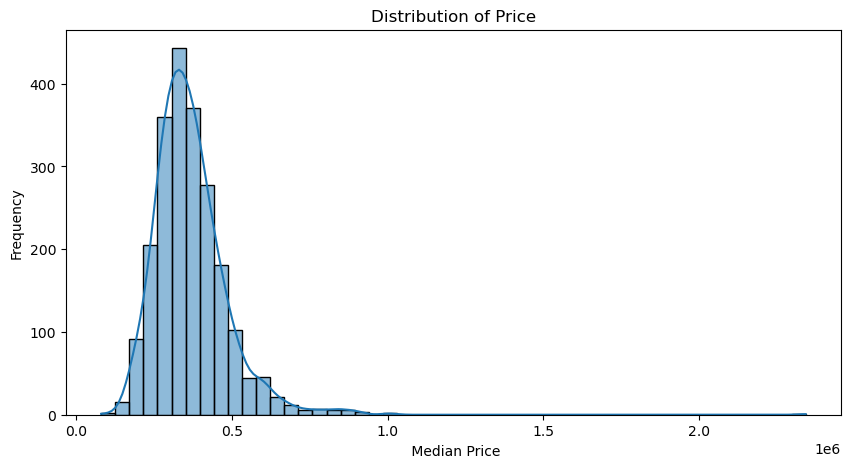

In [5]:
#Checking the skewness of the target variable (median price) to decide whether to log transform to normalise distribution 
plt.figure(figsize=(10,5))
sns.histplot(training_data['median_price'],bins =50, kde=True)
plt.title("Distribution of Price")
plt.xlabel(" Median Price")
plt.ylabel("Frequency")
plt.show()

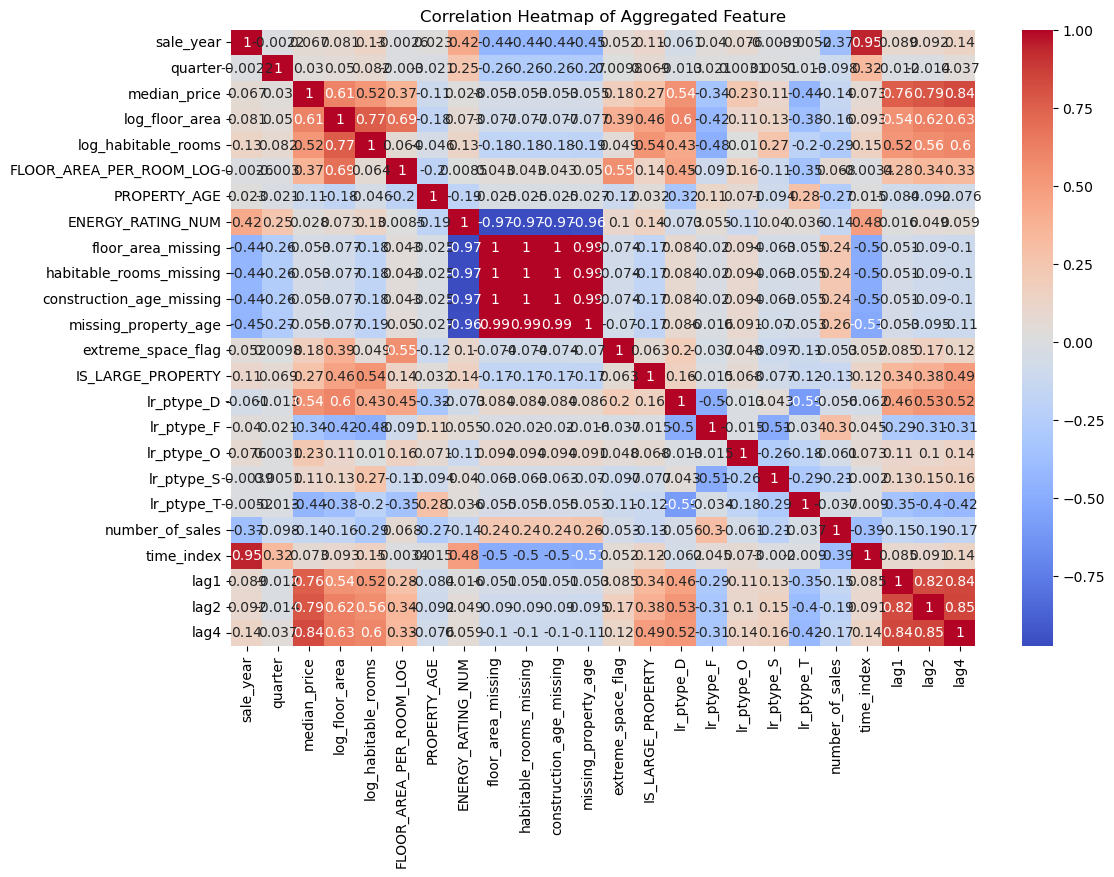

In [6]:
#Correlation heatmap of aggregated features
plt.figure(figsize=(12,8))
sns.heatmap(training_data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Aggregated Feature")
plt.show()

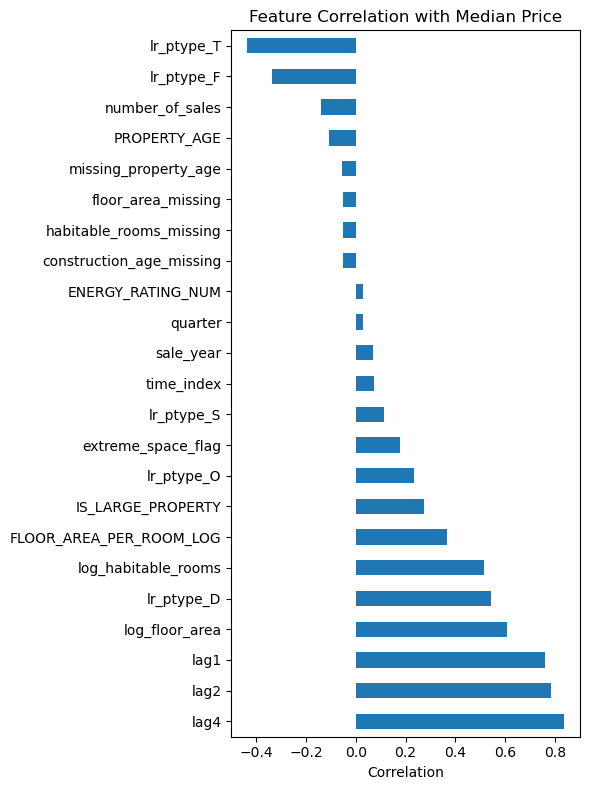

median_price                1.000000
lag4                        0.837088
lag2                        0.785618
lag1                        0.758463
log_floor_area              0.607810
lr_ptype_D                  0.541777
log_habitable_rooms         0.515097
FLOOR_AREA_PER_ROOM_LOG     0.366795
IS_LARGE_PROPERTY           0.272585
lr_ptype_O                  0.233604
extreme_space_flag          0.176927
lr_ptype_S                  0.111956
time_index                  0.073012
sale_year                   0.066792
quarter                     0.030161
ENERGY_RATING_NUM           0.028233
construction_age_missing   -0.052994
habitable_rooms_missing    -0.052994
floor_area_missing         -0.052994
missing_property_age       -0.054787
PROPERTY_AGE               -0.107040
number_of_sales            -0.142355
lr_ptype_F                 -0.335379
lr_ptype_T                 -0.437101
Name: median_price, dtype: float64


In [7]:
numeric_df = training_data.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
price_corr = corr_matrix['median_price'].sort_values(ascending=False)
plt.figure(figsize=(6,8))
price_corr.drop('median_price').plot(kind='barh')
plt.title("Feature Correlation with Median Price")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

print(price_corr)

In [8]:
print(msoa_df['sale_year'])

0       2021
1       2022
2       2023
3       2021
4       2022
        ... 
2927    2023
2928    2024
2929    2024
2930    2024
2931    2024
Name: sale_year, Length: 2932, dtype: int64


In [9]:
#split the data into training and testing 
#Identifer variables and price derived features were removed to ensure model learned only from explanatory characteristics
X_train = training_data.drop(columns=['median_price','MSOA_code'])
#target variable is log transformed to reduce skewness. 
y_train = np.log1p(training_data['median_price'])
X_test = testing_data.drop(columns=['median_price','MSOA_code'])
y_test = testing_data['median_price']


In [10]:
#We use Time Series cross validation instead of normal cv to ensure training set only contains data from 2021-2023
unique_times = sorted(training_data['time_index'].unique())
#Expanding split
splits = []
for i in range(len(unique_times)-1):
    train_time = unique_times[i]
    val_time = unique_times[i+1]
    splits.append((train_time, val_time))
                                                    

In [11]:
#models used to train
models= {
            'RandomForest':{
                'model':RandomForestRegressor(random_state=42),
                'params':{
                    'n_estimators':[150,250],
                    'max_depth':[8,12],
                    'min_samples_split':[2,5]
                },
                
            },
            'XGBoost':{
                'model':xgb.XGBRegressor(
                    random_state = 42, 
                    objective = 'reg:squarederror',
                    n_jobs = 1
                ),
                'params':{
                    'n_estimators':[200,400],
                    'max_depth':[3,4],
                    'learning_rate':[0.03,0.05],
                    'subsample':[0.8],
                    'colsample_bytree':[0.8]
                },
              
            }
        
        }

In [12]:
splits = splits[-8:]
scores = [] 
for model_name, config in models.items():
    print(f"\nTraining {model_name}...")
    best_score = np.inf
    best_params = None
    #manual grid search with defined parameter
    for params in ParameterGrid(config['params']):
        rmse_scores_each_rolling = []
        for train_time, val_time in splits:
            train_split = training_data[training_data['time_index']<=train_time]
            val_split = training_data[training_data['time_index']==val_time]
            if len(train_split) ==0 or len(val_split)==0:
                continue
            
            X_train_rolling_split = train_split.drop(columns=['median_price','MSOA_code'])
            y_training_rolling_split = np.log1p(train_split['median_price'])
            sample_weights = train_split['number_of_sales'].to_numpy()
             
            X_val_rolling_split = val_split.drop(columns=['median_price','MSOA_code'])
            y_val_rolling_split = np.log1p(val_split['median_price'])

            #fresh model every time
            model = config['model'].__class__(**config['model'].get_params())
            model.set_params(**params)
             
            model.fit(X_train_rolling_split, y_training_rolling_split, sample_weight = sample_weights)

            y_predict_rolling_split = model.predict(X_val_rolling_split)
            rmse = np.sqrt(mean_squared_error(y_val_rolling_split, y_predict_rolling_split))
            rmse_scores_each_rolling.append(rmse)
        #Debugging to check if the list is empty 
        if len(rmse_scores_each_rolling)==0:
            continue
        avg_rmse = np.mean(rmse_scores_each_rolling)
        if avg_rmse < best_score:
            best_score = avg_rmse
            best_params = params
        
    final_model = config['model'].__class__(**config['model'].get_params())
    final_model.set_params(**best_params)
    final_model.fit(X_train, y_train, sample_weight = training_data['number_of_sales'])
    #predict the average prices(logged)
    y_predict_log = final_model.predict(X_test)
    #Back tranform log values
    y_predict = np.expm1(y_predict_log)
            
    
    rmse = np.sqrt(mean_squared_error(y_test, y_predict))
    mae = mean_absolute_error(y_test, y_predict)
    r2 = r2_score(y_test,y_predict)
    rmse_log = np.sqrt(mean_squared_error(np.log1p(y_test), y_predict_log))
    scores.append({
        'model':model_name, 
        'best_params':best_params,
        'cv_rmse':best_score,
        'test_rmse':rmse, 
        'mae':mae,
        'r2':r2,
        'rmse_log':rmse_log
    })
results = pd.DataFrame(scores).sort_values('mae')
print(results)

        


Training RandomForest...

Training XGBoost...
          model                                        best_params   cv_rmse  \
0  RandomForest  {'max_depth': 12, 'min_samples_split': 2, 'n_e...  0.145221   
1       XGBoost  {'colsample_bytree': 0.8, 'learning_rate': 0.0...  0.138937   

      test_rmse           mae        r2  rmse_log  
0  47025.642035  31816.175402  0.831597  0.111996  
1  46180.584294  32367.576648  0.837595  0.112237  


In [13]:
#since the user is only feeding in the postcode district, 
#pre save the expected feature column so that the order of feature is preserved 
feature_columns = list(X_train.columns)

In [14]:
X_test_ordered = testing_data[feature_columns]
y_pred_log = final_model.predict(X_test_ordered)
y_pred = np.expm1(y_pred_log)
testing_data['predicted_2024_price'] = y_pred

In [15]:
#aggregating quarter to annual msoa median price
msoa_annual = (
    testing_data.groupby('MSOA_code')
    .apply(lambda x: pd.Series({
        'annual_predicted_price':np.average(
            x['predicted_2024_price'], weights = x['number_of_sales']
        ),
        'total_sales':x['number_of_sales'].sum()
    }),include_groups= False).reset_index()
)
print('MSOA annual prediction',msoa_annual.shape)

MSOA annual prediction (184, 3)


In [16]:
#Merge MSOA on the join table
onspd_path = "../../ONSPD_MAY_2025_UK.csv"
lookup = pd.read_csv(onspd_path,usecols=['pcd','msoa11'])
lookup.rename(columns={
    'pcd':'postcode',
    'msoa11':'MSOA_code'
},inplace= True)
#Clean postcodes for merging 
lookup['postcode'] = lookup['postcode'].str.upper().str.strip()
# Extract outward code (postcode district) from full postcode
lookup['postcode_district'] = lookup['postcode'].str.extract(r'^([A-Z]{1,2}\d{1,2}[A-Z]?)')[0]

#Since one MSOA can overlap different postcode district 
msoa_to_district = (
    lookup.groupby('MSOA_code')['postcode_district']
    .agg(lambda x:x.value_counts().index[0]).reset_index()
    
)

#Merge msoa with the joined table
msoa_annual = msoa_annual.merge(msoa_to_district, on='MSOA_code', how='left')
print("After merge", msoa_annual.shape)



district_predictions = (
    msoa_annual.groupby('postcode_district')
    .apply(lambda x:pd.Series({
        'district_predicted_price':np.average(x['annual_predicted_price'],weights=x['total_sales'])
    }),include_groups =False).reset_index())
print("District prediction", district_predictions.shape)
district_predictions.to_csv("district_prediction_2024.csv",index=False)


After merge (184, 4)
District prediction (71, 2)


In [17]:
district_predictions.head(10)

,postcode_district,district_predicted_price
0,BR8,358121.178209
1,CT1,276382.452416
2,CT10,363965.002444
3,CT11,271231.331901
4,CT12,298842.805913
5,CT13,350543.319444
6,CT14,328244.629936
7,CT15,352839.299238
8,CT16,262099.700773
9,CT17,188861.324896


In [18]:
district_predictions.duplicated(['postcode_district']).sum()

np.int64(0)

Capturing the rate of change of median price per year

In [19]:
historical_data = msoa_df[msoa_df['sale_year'].isin([2021,2022,2023])].copy()

In [20]:
historical_data.duplicated(['MSOA_code','sale_year','quarter']).sum()

np.int64(0)

In [21]:
#Annual weighted median at MSOA level per year 2021,2022,2023
msoa_historical_annual = (
    historical_data.groupby(['MSOA_code','sale_year'])
    .apply(lambda x:pd.Series({
        'annual_historical_price':np.average(x['median_price'],weights = x['number_of_sales']),
        'total_sales':x['number_of_sales'].sum()
    }),include_groups = False).reset_index()

)

In [22]:
#Merge msoa with the joined table
msoa_historical_annual = msoa_historical_annual.merge(msoa_to_district, on='MSOA_code', how='left')


In [23]:
#Aggregate to district level per year for 2021,2022,2023
district_historical_annual = (
    msoa_historical_annual.groupby(['postcode_district','sale_year'])
    .apply(lambda x:pd.Series({
        'district_historical_price' :np.average(x['annual_historical_price'], weights= x['total_sales'])
    }), include_groups = False).reset_index()
)

In [24]:
#Reshape the column
district_wide = district_historical_annual.pivot(
    index = 'postcode_district',
    columns = 'sale_year',
    values='district_historical_price'
).reset_index()
district_wide.columns = ['postcode_district', 'price_2021','price_2022','price_2023']
print(district_wide)

   postcode_district     price_2021     price_2022     price_2023
0                BR6  528750.000000  646000.000000  587000.000000
1                BR8  370743.820225  404644.036697  366471.428571
2                CT1  296684.987358  283082.195274  280616.274510
3               CT10  355908.284024  370590.322581  365653.731527
4               CT11  258392.996109  282068.071809  285801.397206
..               ...            ...            ...            ...
70               TN3  644453.125000  765119.428571  646184.210526
71              TN30  405941.406250  426682.131148  445116.959064
72               TN4  413333.931777  466871.035941  424193.396226
73               TN8  484706.940874  521873.376623  507848.110048
74               TN9  367519.551724  351741.344196  345923.867069

[75 rows x 4 columns]


In [25]:
#Merge it with the predicted price for 2024
district_wide = district_wide.merge(
    district_predictions,
    on='postcode_district',
    how ='inner'
).rename(columns={'district_predicted_price':'price_2024_predicted'})

In [26]:
#Capturing the trend
district_wide['change_2021_2022'] = (
    (district_wide['price_2022']-district_wide['price_2021'])/district_wide['price_2021'] *100
).round(2)
district_wide['change_2022_2023'] = (
    (district_wide['price_2023']-district_wide['price_2022'])/district_wide['price_2022'] *100
).round(2)
district_wide['change_2023_2024'] = (
    (district_wide['price_2024_predicted']-district_wide['price_2023'])/district_wide['price_2023'] *100
).round(2)
print(district_wide)

   postcode_district     price_2021     price_2022     price_2023  \
0                BR8  370743.820225  404644.036697  366471.428571   
1                CT1  296684.987358  283082.195274  280616.274510   
2               CT10  355908.284024  370590.322581  365653.731527   
3               CT11  258392.996109  282068.071809  285801.397206   
4               CT12  271601.496259  295245.856354  276264.762295   
..               ...            ...            ...            ...   
65               TN3  644453.125000  765119.428571  646184.210526   
66              TN30  405941.406250  426682.131148  445116.959064   
67               TN4  413333.931777  466871.035941  424193.396226   
68               TN8  484706.940874  521873.376623  507848.110048   
69               TN9  367519.551724  351741.344196  345923.867069   

    price_2024_predicted  change_2021_2022  change_2022_2023  change_2023_2024  
0          358121.178209              9.14             -9.43             -2.28  
1        

In [27]:
#Check for missing postcode district 
pred_districts = set(district_predictions['postcode_district'])
hist_districts = set(district_historical_annual['postcode_district'])
print("Prediction district:",len(pred_districts))
print("Historical district:",len(hist_districts))

#What is in historical but not in predictions
print("\nIn historical but not in predictions:",hist_districts-pred_districts)

#What is in predictions but not in historical
print("\nIn predictions but not in historical:",pred_districts-hist_districts)

Prediction district: 71
Historical district: 75

In historical but not in predictions: {'RH7', 'ME4', 'ME7', 'BR6', 'ME5'}

In predictions but not in historical: {'ME8'}


In [28]:
print(district_wide[['price_2021', 'price_2022', 'price_2023', 'price_2024_predicted']].isna().sum())

price_2021              0
price_2022              0
price_2023              0
price_2024_predicted    0
dtype: int64


In [29]:
district_wide.to_csv("district_price_changes.csv",index=False)

/var/folders/s8/w4y89hhs6x765p8_wndr93th0000gn/T/ipykernel_58247/2796720222.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y = 'Feature',data=feature_importance_df, palette='viridis')


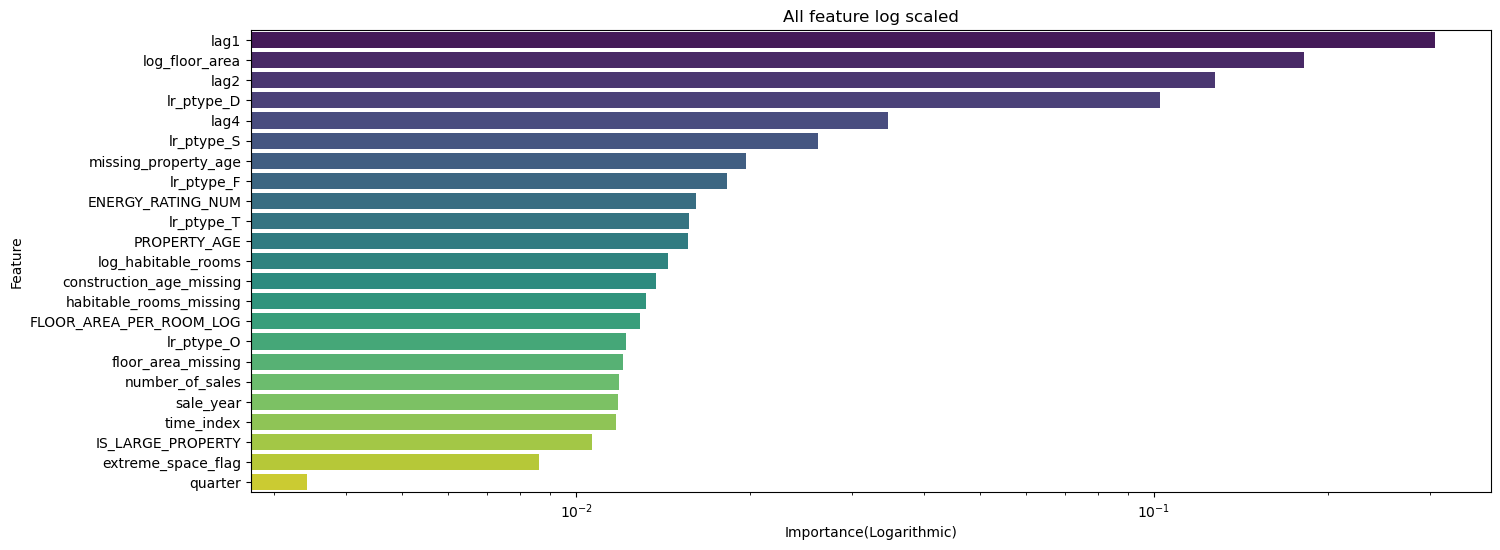

/var/folders/s8/w4y89hhs6x765p8_wndr93th0000gn/T/ipykernel_58247/2796720222.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Relative_Importance', y = 'Feature',data=structure_only, palette='magma')


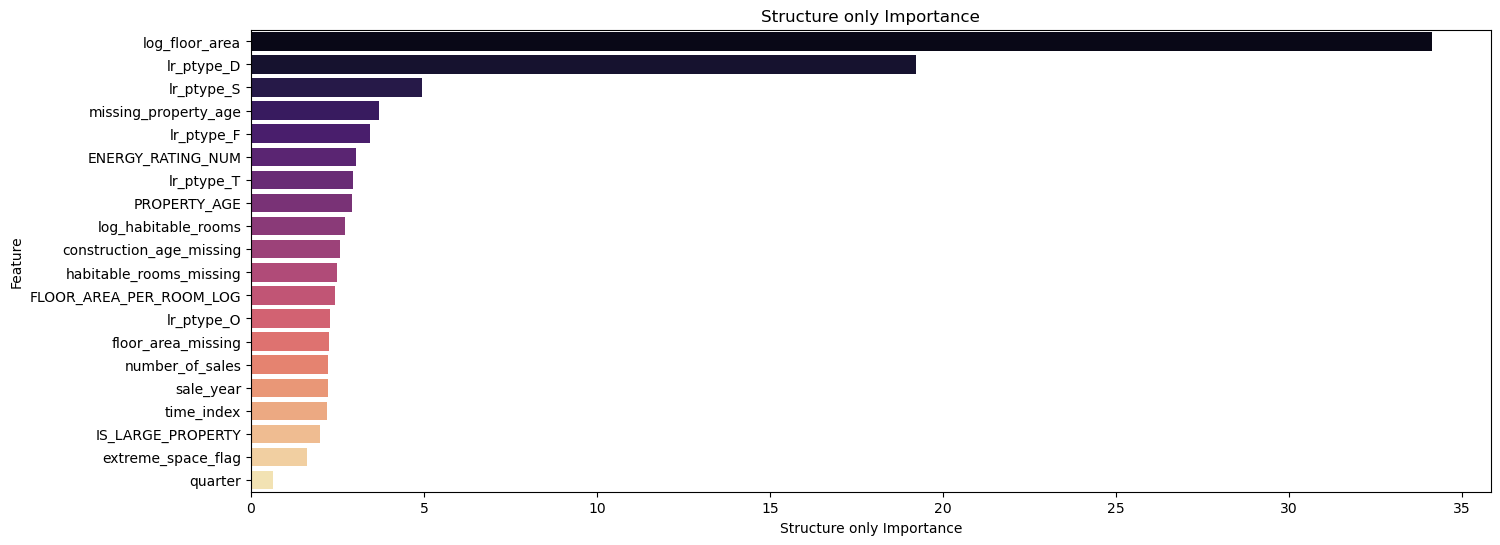

Location:30.57%
Structure:69.43%


In [30]:
#creating feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature':X_train.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance',ascending=False)

lag_features = ['lag1','lag2','lag4']

structure_only= feature_importance_df[~feature_importance_df['Feature'].isin(lag_features)].copy()
structure_only['Relative_Importance'] =  (structure_only['Importance']/structure_only['Importance'].sum())*100
plt.figure(figsize=(16,6))
sns.barplot(x='Importance', y = 'Feature',data=feature_importance_df, palette='viridis')
plt.xlabel('Importance(Logarithmic)')
plt.xscale('log')
plt.title('All feature log scaled')
plt.show()

plt.figure(figsize=(16,6))
sns.barplot(x='Relative_Importance', y = 'Feature',data=structure_only, palette='magma')
plt.xlabel('Structure only Importance')
plt.title('Structure only Importance')
plt.show()

msoa_val= feature_importance_df[feature_importance_df['Feature'].isin(lag_features)]['Importance'].values[0]
print(f'Location:{msoa_val:.2%}')
print(f'Structure:{(1-msoa_val):.2%}')

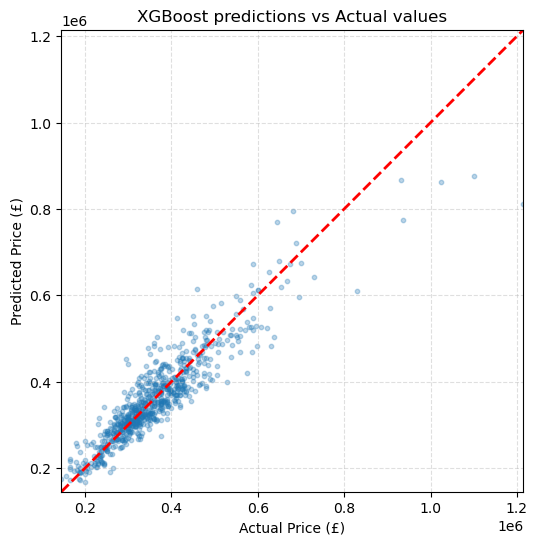

In [38]:
#Creating scatter plot to visualise the predicted and actual price using XGBoost
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(
    y_test,
    y_pred,
    alpha= 0.3,
    s=10
    
)
lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]
ax.plot(lims, lims, 'r--',  lw=2)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.grid(True, linestyle="--", alpha = 0.4)

ax.set_aspect('equal')

ax.set(
    xlabel= "Actual Price (£)",
    ylabel= "Predicted Price (£)",
    title = "XGBoost predictions vs Actual values"
    
)
plt.show()

In [39]:
checks ={
    'median_price not in X_train':'median_price' not in X_train.columns,
    'median_price not in X_test':'median_price' not in X_test.columns,
    'MSOA_code not in X_train':'MSOA_code' not in X_train.columns,
    'MSOA_code not in X_test':'MSOA_code' not in X_test.columns,
    'Train years <2024': training_data['sale_year'].max()<2024,
    'Test year ==2024': testing_data['sale_year'].min()==2024,
}

for check, result in checks.items():
    print(f"{check}:{result}")

median_price not in X_train:True
median_price not in X_test:True
MSOA_code not in X_train:True
MSOA_code not in X_test:True
Train years <2024:True
Test year ==2024:True


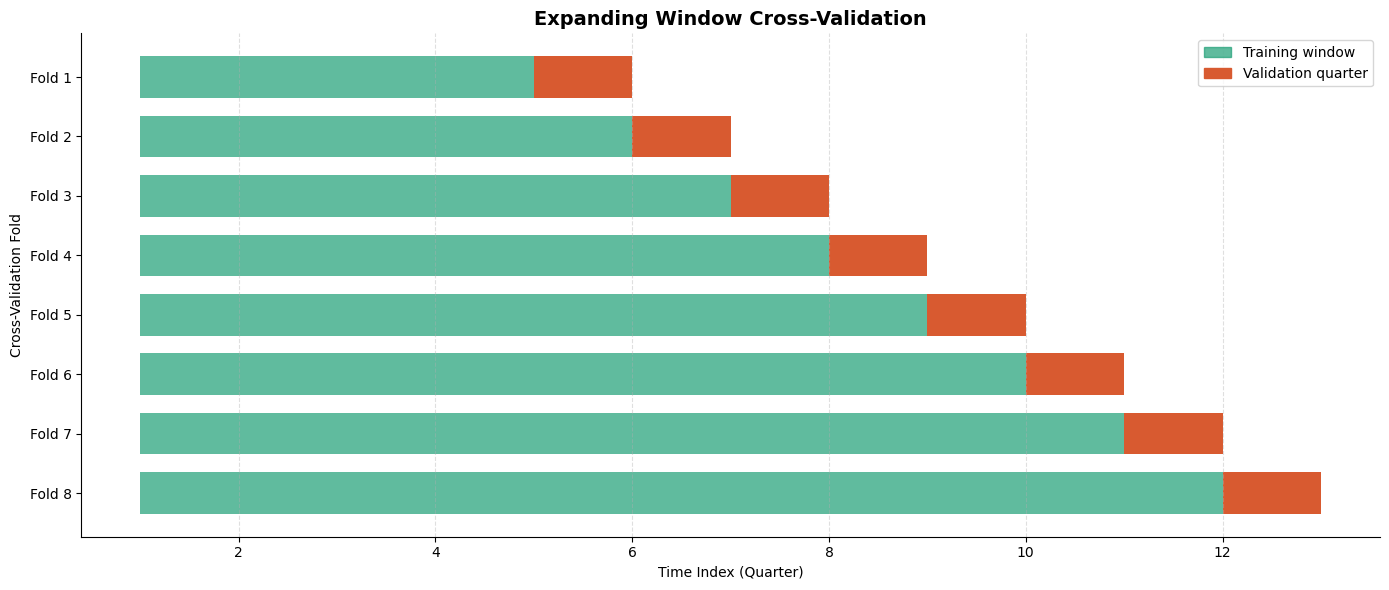

In [44]:
fold_label= [f"Fold {i+1}" for i in range(len(splits))]
fig, ax = plt.subplots(figsize= (14,6))
for fold_index, (train_time, val_time) in enumerate(splits):
    train_start= unique_times[0]
    train_width = train_time-train_start +1

    ax.broken_barh(
        [(train_start, train_width)],
        (fold_index - 0.35, 0.7),
        facecolors="#1D9E75",
        alpha=0.7
    )

    ax.broken_barh(
        [(val_time, 1)],
        (fold_index - 0.35, 0.7),
        facecolors="#D85A30"
    )

ax.set_yticks(range(len(splits)))
ax.set_yticklabels(fold_label)

ax.set_xlabel("Time Index (Quarter)")
ax.set_ylabel("Cross-Validation Fold")

ax.set_title(
    "Expanding Window Cross-Validation",
    fontsize=14,
    fontweight='bold'
)

ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(handles=[
    mpatches.Patch(color="#1D9E75", alpha=0.7,
                    label='Training window'),
    
    mpatches.Patch(color="#D85A30",
                    label='Validation quarter')
])

ax.invert_yaxis()
plt.tight_layout()
plt.show()